In [3]:
import pandas as pd

# Load the data (Make sure the filename is exactly as saved)
df = pd.read_csv('cleaned_data.csv')

# Inspect the first 5 rows (Data discovery)
print("--- First 5 Rows of the Dataset ---")
display(df.head())

# Check data types and overall structure
print("\n--- Data Types and Structure ---")
df.info()

--- First 5 Rows of the Dataset ---


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Data Types and Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentM

In [4]:
# --- 2. STATISTICAL SUMMARY (For Numerical Data) ---
print("Statistical Summary of Numerical Columns:")
display(df.describe())

# --- 3. TARGET VARIABLE (CHURN) DISTRIBUTION ---
print("\nTotal Customer Churn Counts:")
print(df['Churn'].value_counts())

# --- 4. RELATIONSHIP DISCOVERY (Which Contract Types Churn More?) ---
print("\nChurn Status by Contract Type:")
display(pd.crosstab(df['Contract'], df['Churn']))

Statistical Summary of Numerical Columns:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000



Total Customer Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Status by Contract Type:


Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


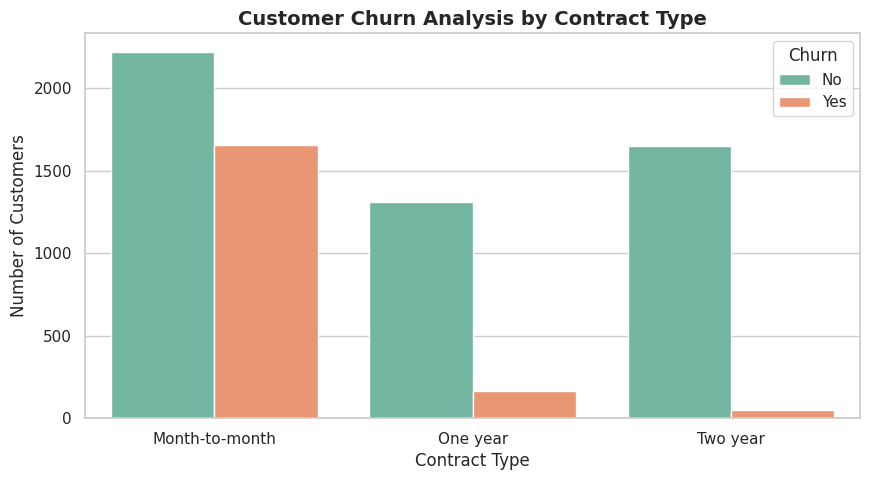

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 5. DATA VISUALIZATION ---

# Set the plot style and figure size
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Visualization 1: Churn by Contract Type
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))

# Bar chart of Churn by Contract type
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')

# Add title and labels to the plot
plt.title('Customer Churn Analysis by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Display the plot
plt.show()



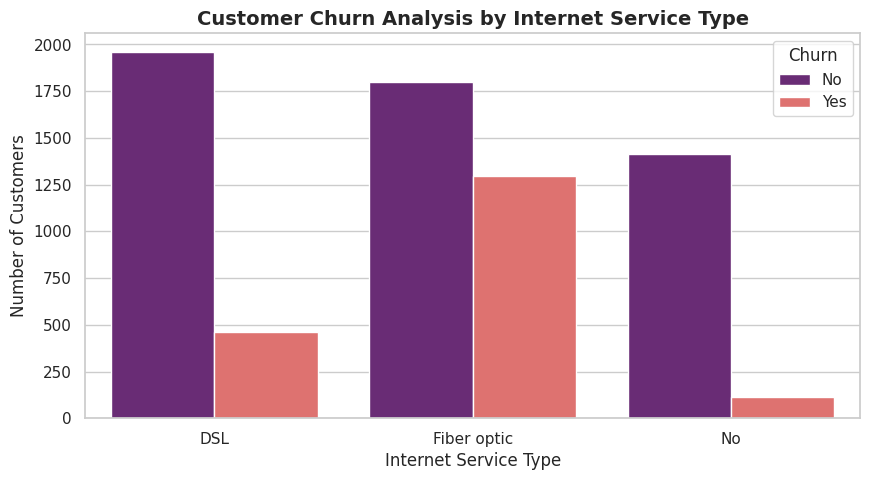

In [6]:
# --- Visualization: Churn by Internet Service Type ---

# Set figure size
plt.figure(figsize=(10, 5))

# Create a bar chart of Churn grouped by Internet Service
sns.countplot(x='InternetService', hue='Churn', data=df, palette='magma')

# Add title and labels to the plot
plt.title('Customer Churn Analysis by Internet Service Type', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Display the plot
plt.show()

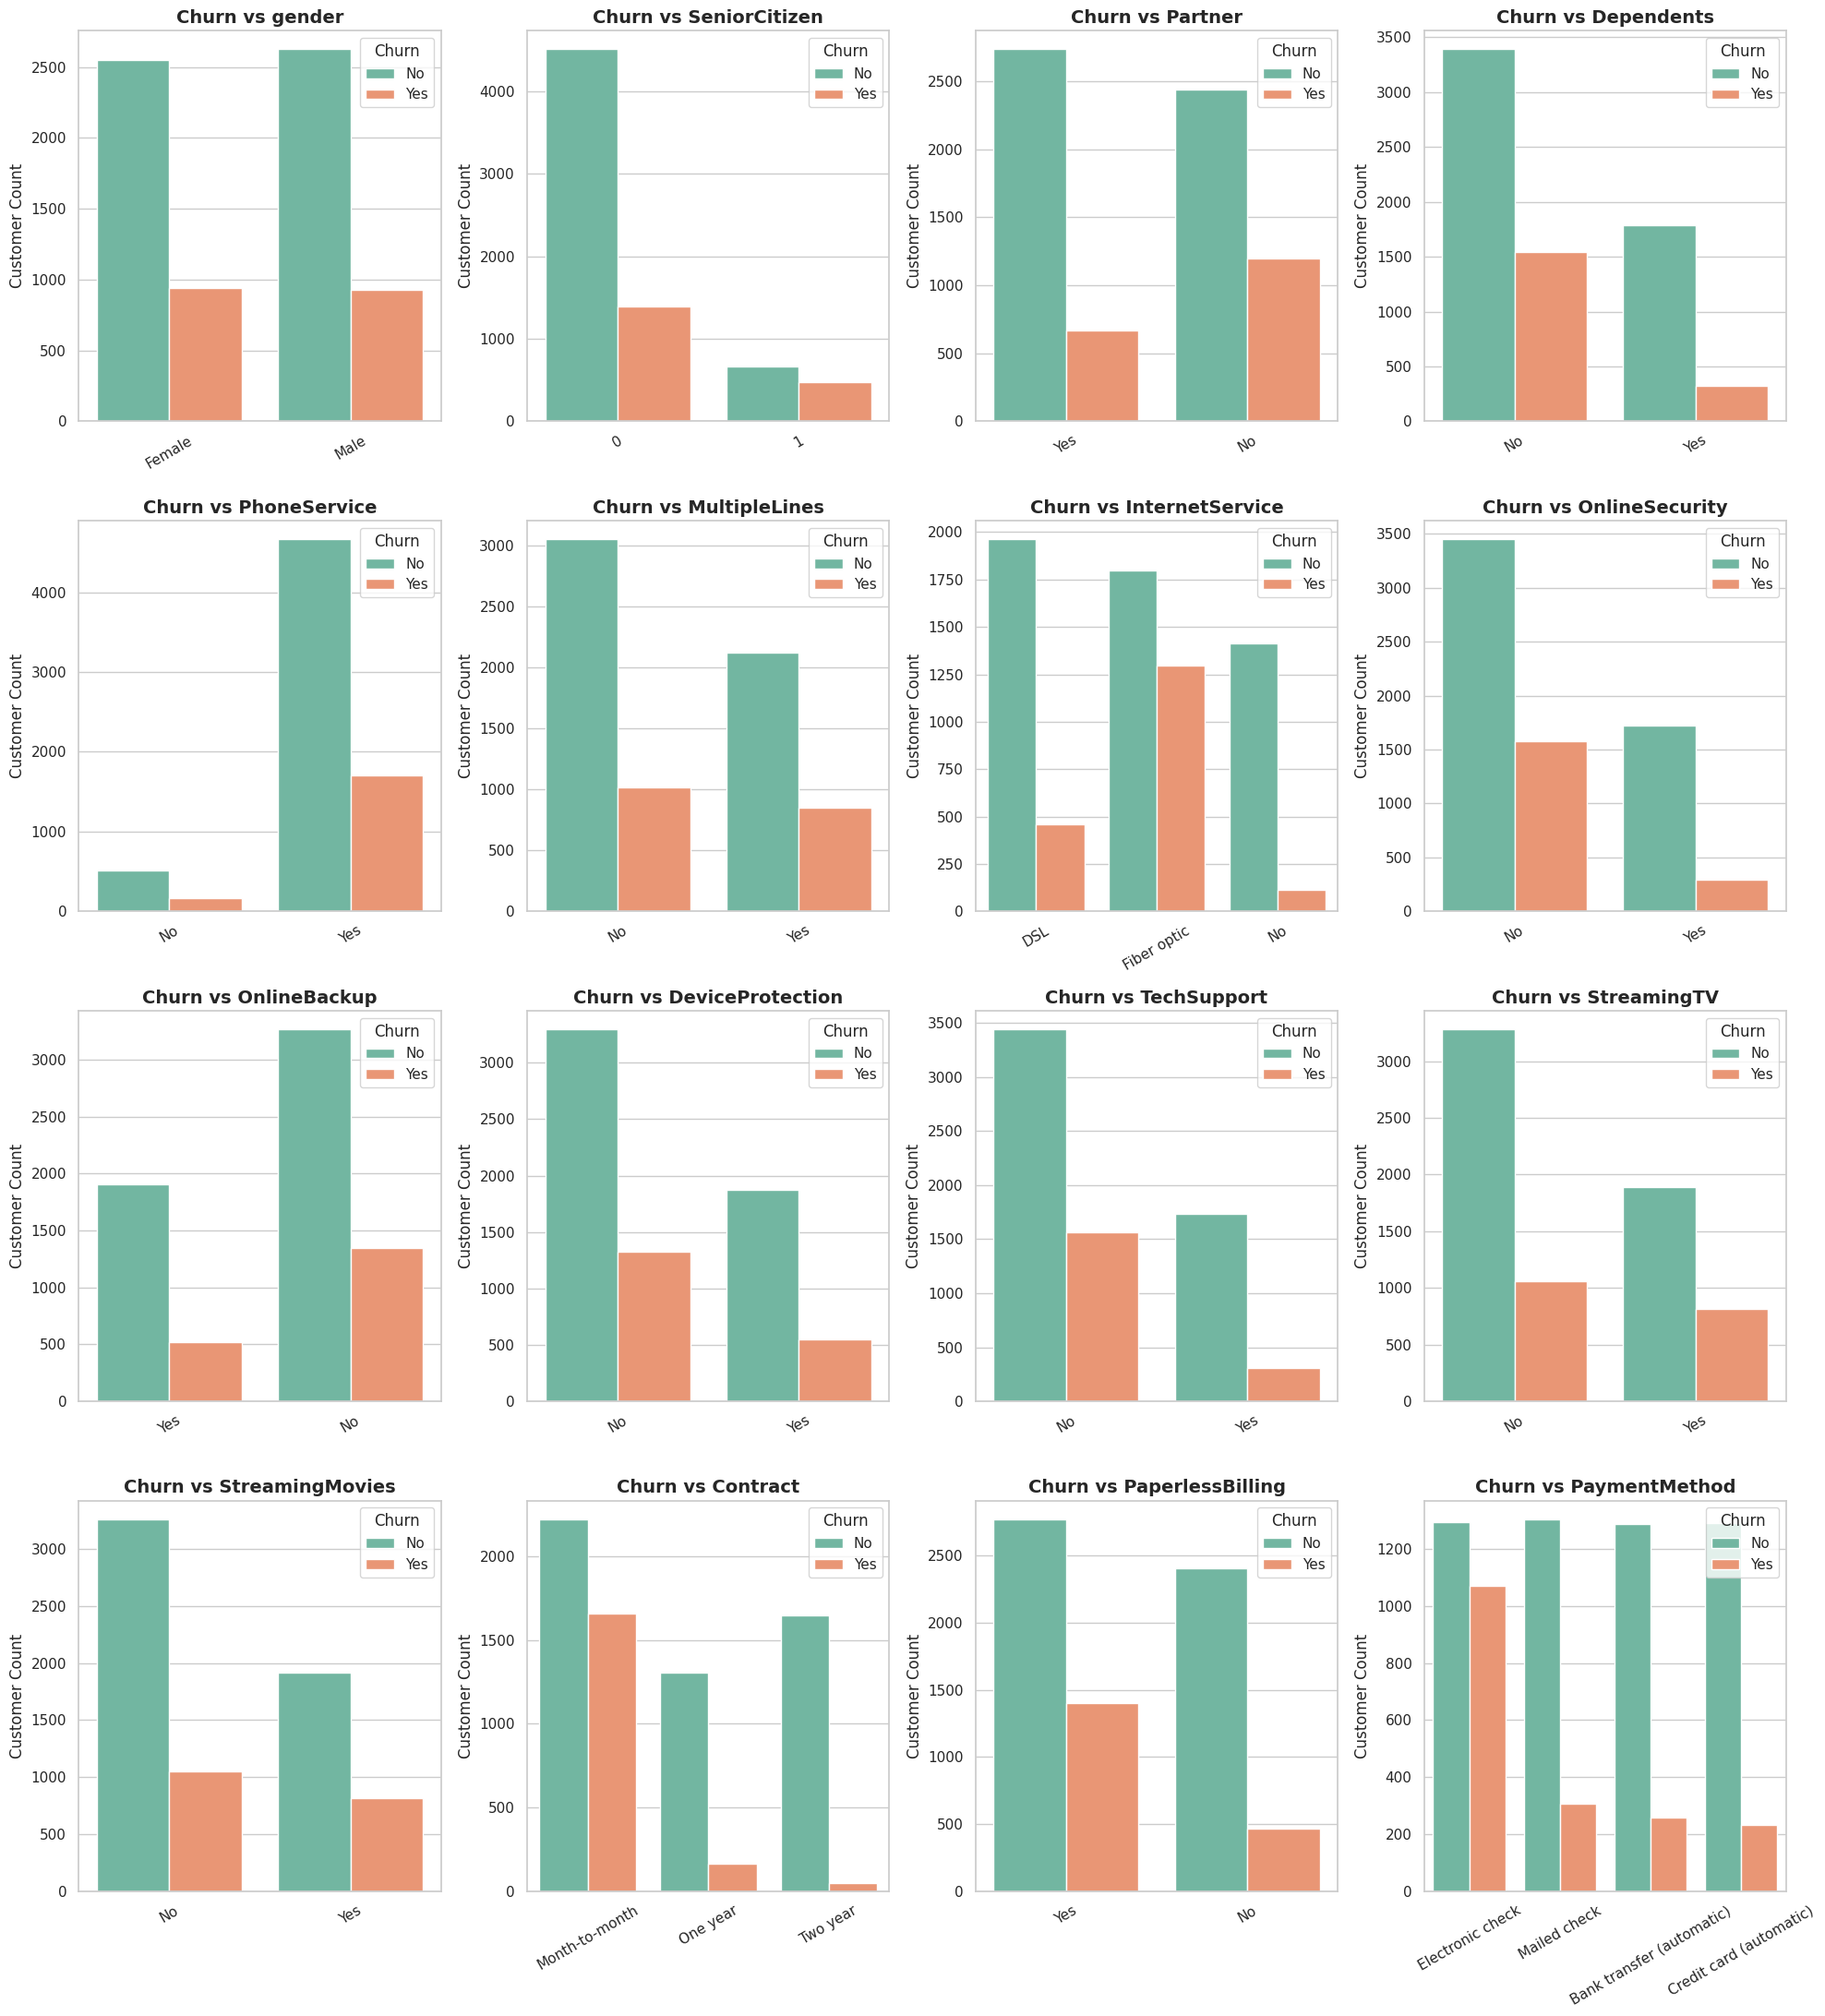

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reload the original data (with text labels) specifically for this visualization
df_eda = pd.read_csv('cleaned_data.csv')

# 2. List of categorical features
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

# 3. Create a 4x4 grid of subplots for 16 charts
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 22))
axes = axes.flatten()

# 4. Loop through features and plot them against Churn
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df_eda, x=col, hue='Churn', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Churn vs {col}', fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Customer Count')

plt.tight_layout()
plt.show()

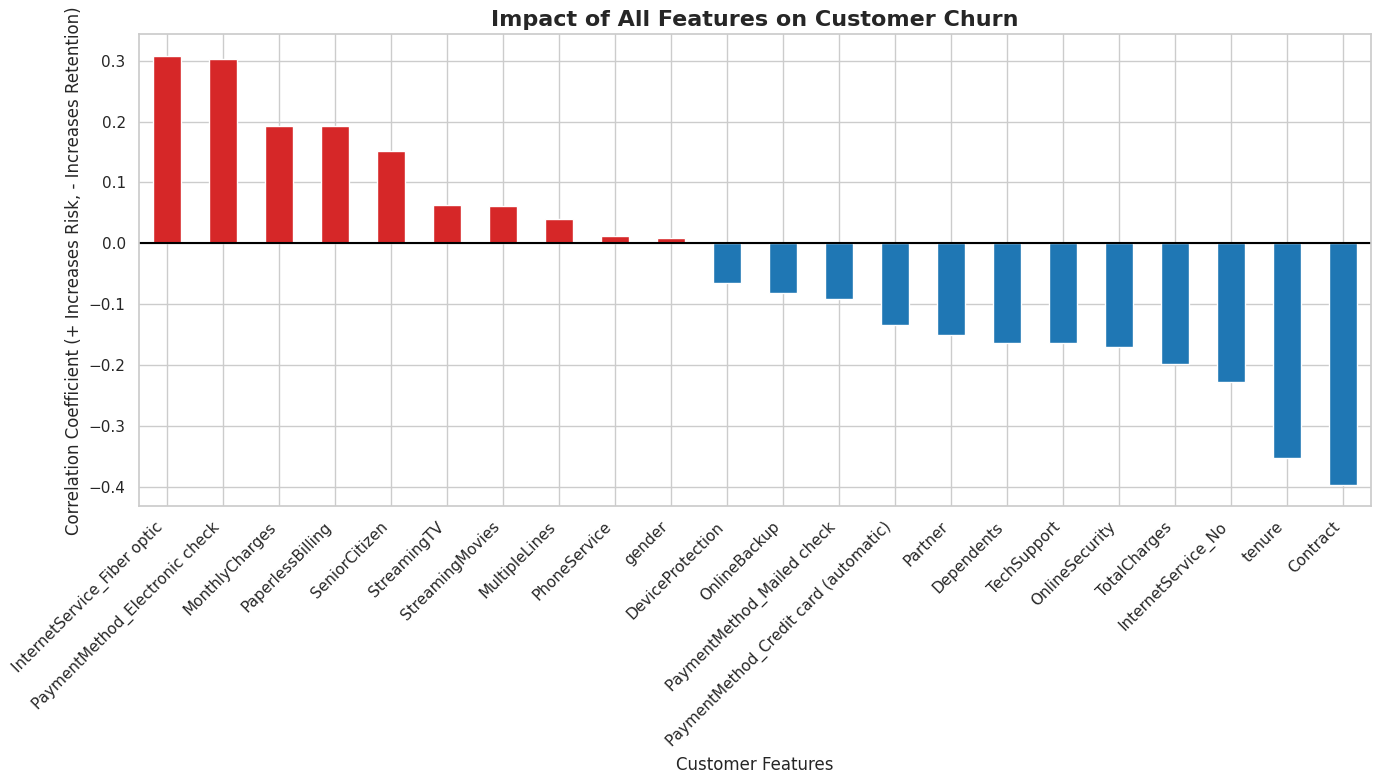

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the cleaned data
df = pd.read_csv('cleaned_data.csv')

# =====================================================================
# 2. FEATURE ENCODING FOR CORRELATION ANALYSIS
# =====================================================================
# Define binary columns for 0/1 encoding
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    if col == 'gender':
        df[col] = df[col].map({'Female': 1, 'Male': 0})
    else:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# Ordinal encoding for Contract type
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

# One-Hot Encoding for remaining categorical variables
df = pd.get_dummies(data=df, columns=['PaymentMethod', 'InternetService'], drop_first=True)


# =====================================================================
# 3. CORRELATION ANALYSIS: ALL FEATURES VS CHURN
# =====================================================================
plt.figure(figsize=(14, 8))

# Calculate correlation with Churn, drop Churn itself, and sort values
churn_corr = df.corr()['Churn'].drop('Churn').sort_values(ascending=False)

# Color coding: Red for positive correlation (increases churn risk), Blue for negative (retention)
colors = ['#d62728' if x > 0 else '#1f77b4' for x in churn_corr]
churn_corr.plot(kind='bar', color=colors)

# Add titles and labels
plt.title('Impact of All Features on Customer Churn', fontsize=16, fontweight='bold')
plt.ylabel('Correlation Coefficient (+ Increases Risk, - Increases Retention)', fontsize=12)
plt.xlabel('Customer Features', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()